# **Graph Machine Learning**

Andrés Santos Tovar

David Leonardo Sánchez

Leonardo Becerra

María Paula Ramos Rodríguez

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from random import randint

%matplotlib inline

In [ ]:
import torch
!pip install -q torch-scatter~=2.1.0 torch-sparse~=0.6.16 torch-cluster~=1.6.0 torch-spline-conv~=1.2.1 torch-geometric==2.2.0 -f https://data.pyg.org/whl/torch-{torch.__version__}.html

torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.cuda.manual_seed_all(0)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 18.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 25.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 565.0/565.0 kB 8.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


## **Facebook Page-Page dataset**

This dataset was introduced by Rozemberczki et al. in 2019. It was created using the Facebook Graph API in November 2017. In this dataset, each of the 22,470 nodes represents an official Facebook page. Pages are connected when there are mutual likes between them. Node features (128-dim vectors) are created from textual descriptions written by the owners of these pages. Our goal is to classify each node into one of four categories:

- politicians
- companies
- television shows
- governmental organizations.

The Facebook Page-Page dataset is similar to the previous one: it’s a social network with a node classification task. However, there are three major differences with Cora:

The number of nodes is much higher (2,708 versus 22,470) The dimensionality of the node features decreased dramatically (from 1,433 to 128) The goal is to classify each node into four categories instead of seven (which is easier since there are fewer options) The following figure is a visualization of the dataset using Gephi. First, nodes with few connections have been filtered out to improve performance. The size of the remaining nodes depends on their number of connections, and their color indicates the category they belong to. Finally, two layouts have been applied: Fruchterman-Reingold and ForceAtlas2.

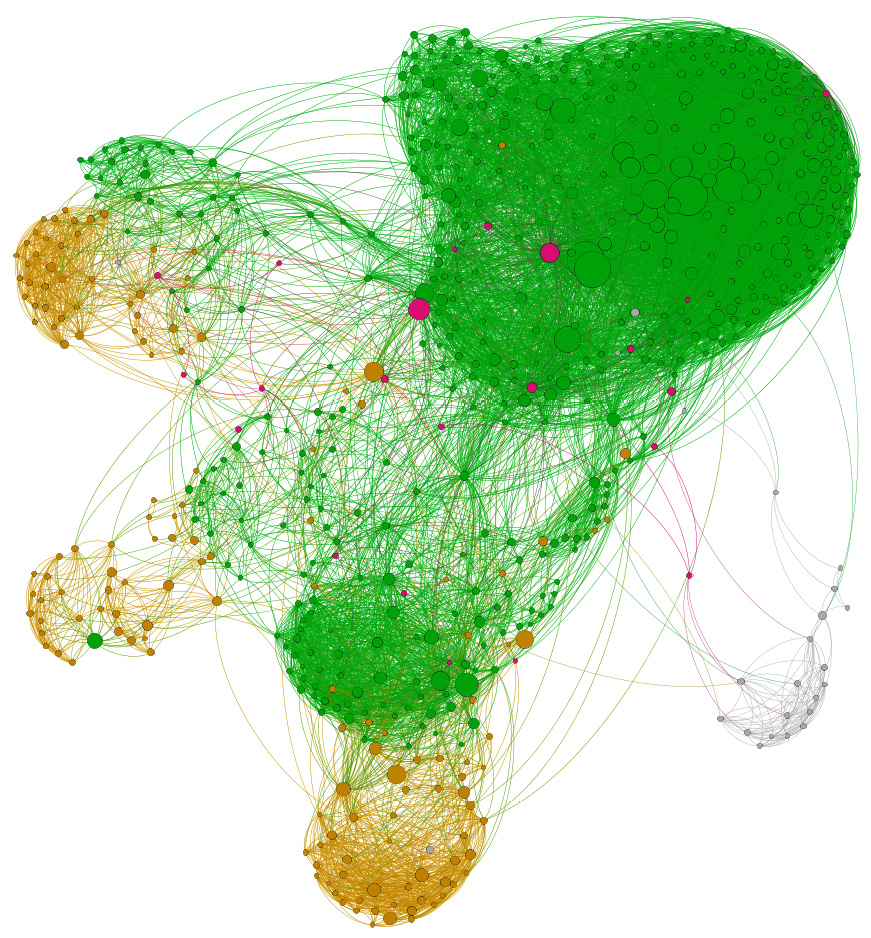

## **Load dataset**

In [ ]:
# Importar las bibliotecas necesarias
import torch
from torch_geometric.data import Data
from torch_geometric.datasets import FacebookPagePage
# Import the specific classes causing the unpickling error
from torch_geometric.data.data import DataEdgeAttr, DataTensorAttr
from torch_geometric.data.storage import GlobalStorage # Import GlobalStorage

# Agregar las clases necesarias a los globales seguros
# Add GlobalStorage to the list of safe globals
torch.serialization.add_safe_globals([Data, DataEdgeAttr, DataTensorAttr, GlobalStorage])

# Cargar el dataset
dataset = FacebookPagePage(root=".")
data = dataset[0]

# Imprimir información sobre el dataset
print(f'Dataset: {dataset}')
print('-----------------------')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of nodes: {data.x.shape[0]}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

# Print information about the graph
print(f'\nGraph:')
print('------')
print(f'Edges are directed: {data.is_directed()}')
print(f'Graph has isolated nodes: {data.has_isolated_nodes()}')
print(f'Graph has loops: {data.has_self_loops()}')

# Crear máscaras para train/val/test
data.train_mask = range(18000)
data.val_mask = range(18001, 20000)
data.test_mask = range(20001, 22470)

Dataset: FacebookPagePage()
-----------------------
Number of graphs: 1
Number of nodes: 22470
Number of features: 128
Number of classes: 4

Graph:
------
Edges are directed: False
Graph has isolated nodes: False
Graph has loops: True


El conjunto de datos Facebook Page-Page representa una red social de páginas de Facebook, estructurada como un grafo con las siguientes características principales:

- Contiene un único grafo conectado que engloba toda la red de páginas
- La red está compuesta por 22,470 nodos, donde cada nodo representa una página oficial de Facebook
- Cada página (nodo) está caracterizada por un vector de 128 dimensiones, que representa características extraídas de las descripciones textuales de las páginas

El grafo tiene las siguientes propiedades:
- Las aristas no son dirigidas
- No hay nodos aislados
- El grafo contiene bucles (conexiones de un nodo consigo mismo)

El problema de clasificación consiste en categorizar cada página en una de las cuatro clases disponibles:
    - Políticos
    - Empresas
    - Programas de televisión
    - Organizaciones gubernamentales


## **Visualizing the graph**

Para visualizar y analizar la estructura del grafo de Facebook Page-Page, implementaremos una estrategia de muestreo debido al gran tamaño de la red. El proceso se realizará de la siguiente manera:

1. Conversión del Grafo:
- Convertir el grafo de PyTorch Geometric a formato NetworkX para facilitar su visualización y análisis
- Mantener las conexiones originales entre nodos mediante edge_index
1. Muestreo Representativo:
- Seleccionar una muestra aleatoria de 1000 nodos del grafo total
- Esta técnica de submuestreo permite mantener una visualización manejable mientras se preserva la estructura general de la red
1. Visualización:
- Utilizar el algoritmo de layout "spring_layout" para distribuir los nodos de manera óptima
- Configurar parámetros visuales como el tamaño de los nodos, colores y transparencia para mejorar la legibilidad
1. Análisis Estadístico:
- Se implementará un análisis comparativo entre el grafo completo y la submuestra
- Se calcularán métricas importantes como el número de nodos, aristas y densidad del grafo

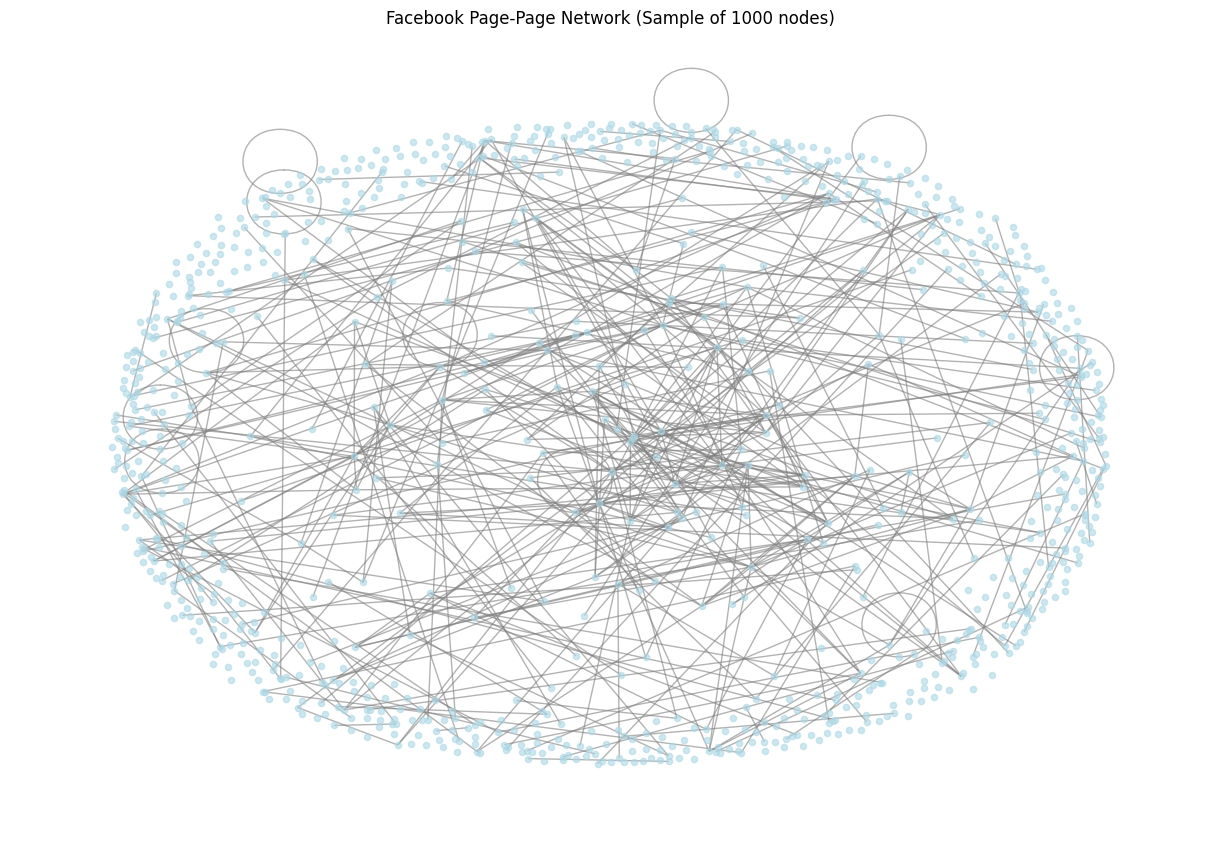

Estadísticas del grafo completo:
Número de nodos: 22470
Número de aristas: 171002
Densidad del grafo: 0.000677

Estadísticas de la submuestra:
Número de nodos: 1000
Número de aristas: 434
Densidad del grafo: 0.000869


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import torch_geometric.utils as utils
import random

# Convertir el grafo de PyTorch Geometric a NetworkX
edge_index = data.edge_index.numpy()
G = nx.Graph()
for i in range(edge_index.shape[1]):
    G.add_edge(edge_index[0,i], edge_index[1,i])

# Seleccionar una submuestra de nodos (por ejemplo, 1000 nodos)
num_nodes_sample = 1000
sampled_nodes = random.sample(list(G.nodes()), num_nodes_sample)
G_sub = G.subgraph(sampled_nodes)

# Configurar el layout del grafo
pos = nx.spring_layout(G_sub, k=0.5, iterations=50)

# Crear la visualización
plt.figure(figsize=(12, 8))
nx.draw(G_sub,
        pos,
        node_size=20,
        node_color='lightblue',
        edge_color='gray',
        alpha=0.6,
        with_labels=False)

plt.title('Facebook Page-Page Network (Sample of 1000 nodes)')
plt.show()

# Imprimir estadísticas del grafo completo y la submuestra
print(f"Estadísticas del grafo completo:")
print(f"Número de nodos: {G.number_of_nodes()}")
print(f"Número de aristas: {G.number_of_edges()}")
print(f"Densidad del grafo: {nx.density(G):.6f}")

print(f"\nEstadísticas de la submuestra:")
print(f"Número de nodos: {G_sub.number_of_nodes()}")
print(f"Número de aristas: {G_sub.number_of_edges()}")
print(f"Densidad del grafo: {nx.density(G_sub):.6f}")


Al analizar la visualización y las estadísticas del grafo de Facebook Page-Page, podemos observar:

Grafo Completo:

- La red completa contiene 22,470 nodos (páginas de Facebook)
- Posee 171,002 aristas (conexiones entre páginas)
- La densidad del grafo es 0.000677, lo que indica una red dispersa, típica de redes sociales reales

Submuestra Visualizada:

- Se muestra una submuestra de 1,000 nodos
- Contiene 434 aristas entre estos nodos
- La densidad es 0.000869, ligeramente mayor que el grafo completo pero mantiene la naturaleza dispersa

La visualización muestra una estructura típica de red social, donde:

- Los nodos (puntos azules claros) representan las páginas de Facebook
- Las líneas grises representan las conexiones entre páginas
- Se pueden observar algunos clusters o agrupaciones de nodos, lo que sugiere la existencia de comunidades de páginas más estrechamente relacionadas entre sí

Esta estructura dispersa y clusterizada es característica de redes sociales reales, donde las páginas tienden a formar comunidades basadas en intereses o categorías similares.

## **Split dataset**

In [ ]:
# Dataset
dataset = FacebookPagePage(root=".")
data = dataset[0]
data.train_mask = range(18000)
data.val_mask = range(18001, 20000)
data.test_mask = range(20001, 22470)

## **Build Adjacency Matrix**

In [ ]:
# Adjacency matrix
from torch_geometric.utils import to_dense_adj

# Crear matriz de adyacencia
adjacency = to_dense_adj(data.edge_index)[0]
adjacency += torch.eye(len(adjacency))
adjacency

tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.]])

## Build MLP class

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class MLP(nn.Module):
    def __init__(self, num_features, hidden_size, num_classes):
        super(MLP, self).__init__()
        self.linear1 = nn.Linear(num_features, hidden_size)
        self.linear2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = F.relu(self.linear1(x))
        x = self.linear2(x)
        return x

En la construcción de la clase MLP (Multilayer Perceptron) se implementó una red neuronal básica con las siguientes características:

- Una arquitectura de dos capas lineales:
    - Primera capa: transforma las 128 características de entrada en un espacio oculto
    - Segunda capa: transforma el espacio oculto en las 4 clases de salida
- Función de activación ReLU entre las capas, que introduce no-linealidad al modelo
- La clase hereda de nn.Module, que es la clase base de PyTorch para todos los modelos de redes neuronales

Este MLP servirá como línea base para comparar con el rendimiento del modelo GNN que implementaremos posteriormente, ya que el MLP solo considera las características de los nodos pero ignora la estructura del grafo.

## **Build GNN class**

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class VanillaGNNLayer(nn.Module):
    def __init__(self, in_features, out_features):
        super(VanillaGNNLayer, self).__init__()
        self.linear = nn.Linear(in_features, out_features, bias=False)

    def forward(self, x, adj):
        x = self.linear(x)
        x = torch.mm(adj, x)
        return x

class GNN(nn.Module):
    def __init__(self, num_features, hidden_size, num_classes):
        super(GNN, self).__init__()
        self.gnn1 = VanillaGNNLayer(num_features, hidden_size)
        self.gnn2 = VanillaGNNLayer(hidden_size, num_classes)

    def forward(self, x, adj):
        x = F.relu(self.gnn1(x, adj))
        x = self.gnn2(x, adj)
        return x

Para el modelo GNN se implementó una arquitectura de red neuronal basada en grafos que consta de dos componentes principales:

1. Capa Base (VanillaGNNLayer):
- Implementa el mecanismo fundamental de procesamiento de grafos
- Realiza una transformación lineal de las características de los nodos
- Ejecuta la agregación de información mediante la matriz de adyacencia
1. Arquitectura GNN:
- Utiliza dos capas VanillaGNNLayer secuenciales para el procesamiento jerárquico
- Primera capa: transforma el espacio de características original (128 dimensiones) en un espacio latente, aplicando una función de activación ReLU
- Segunda capa: proyecta el espacio latente al espacio de clasificación final (4 clases)

Esta arquitectura permite capturar tanto las características individuales de cada página como las relaciones estructurales entre páginas conectadas en la red de Facebook.

## **Run models and compare**

Acontinuación, se realizará una evaluación comparativa entre los modelos MLP y GNN implementados anteriormente. El proceso incluirá:

1. Preparación de datos:
- Conversión de las máscaras de entrenamiento, validación y prueba a tensores de PyTorch
- Configuración de los conjuntos de datos para la evaluación de ambos modelos
1. Configuración del entrenamiento:
- Definición de la función de pérdida (CrossEntropyLoss)
- Configuración de los optimizadores Adam para ambos modelos
1. Proceso de entrenamiento y evaluación:
- Entrenamiento de cada modelo durante 100 épocas
- Evaluación de la precisión en el conjunto de prueba
- Comparación del rendimiento entre ambas arquitecturas

Esta comparación nos permitirá determinar si la incorporación de información estructural del grafo (GNN) mejora significativamente el rendimiento respecto al modelo básico (MLP) en la tarea de clasificación de páginas de Facebook.

In [ ]:
# Convertir las máscaras de range a tensores
data.train_mask = torch.tensor([i in range(18000) for i in range(data.x.shape[0])])
data.val_mask = torch.tensor([i in range(18001, 20000) for i in range(data.x.shape[0])])
data.test_mask = torch.tensor([i in range(20001, 22470) for i in range(data.x.shape[0])])

# Crear instancias de los modelos
mlp_model = MLP(num_features=dataset.num_features, hidden_size=16, num_classes=dataset.num_classes)
gnn_model = GNN(num_features=dataset.num_features, hidden_size=16, num_classes=dataset.num_classes)

# Configurar entrenamiento
criterion = torch.nn.CrossEntropyLoss()
optimizer_mlp = torch.optim.Adam(mlp_model.parameters())
optimizer_gnn = torch.optim.Adam(gnn_model.parameters())

# Mostrar arquitectura de los modelos
print("MLP Architecture:")
print(mlp_model)
print("\nGNN Architecture:")
print(gnn_model)

# Entrenar MLP
print("\nTraining MLP...")
for epoch in range(100):
    mlp_model.train()
    optimizer_mlp.zero_grad()
    out = mlp_model(data.x)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    acc = (out[data.train_mask].argmax(dim=1) == data.y[data.train_mask]).float().mean()
    loss.backward()
    optimizer_mlp.step()

    if epoch % 20 == 0:
        print(f'Epoch {epoch:3d} | Train Loss: {loss.item():.3f} | Train Acc: {acc.item()*100:.2f}%')

# Evaluar MLP
mlp_model.eval()
pred_mlp = mlp_model(data.x).argmax(dim=1)
acc_mlp = pred_mlp[data.test_mask].eq(data.y[data.test_mask]).sum().item() / data.test_mask.sum().item()

# Entrenar GNN
print("\nTraining GNN...")
for epoch in range(100):
    gnn_model.train()
    optimizer_gnn.zero_grad()
    out = gnn_model(data.x, adjacency)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    acc = (out[data.train_mask].argmax(dim=1) == data.y[data.train_mask]).float().mean()
    loss.backward()
    optimizer_gnn.step()

    if epoch % 20 == 0:
        print(f'Epoch {epoch:3d} | Train Loss: {loss.item():.3f} | Train Acc: {acc.item()*100:.2f}%')

# Evaluar GNN
gnn_model.eval()
pred_gnn = gnn_model(data.x, adjacency).argmax(dim=1)
acc_gnn = pred_gnn[data.test_mask].eq(data.y[data.test_mask]).sum().item() / data.test_mask.sum().item()

# Mostrar resultados finales
print("\nFinal Results:")
print(f"MLP test accuracy: {acc_mlp*100:.2f}%")
print(f"GNN test accuracy: {acc_gnn*100:.2f}%")

MLP Architecture:
MLP(
  (linear1): Linear(in_features=128, out_features=16, bias=True)
  (linear2): Linear(in_features=16, out_features=4, bias=True)
)

GNN Architecture:
GNN(
  (gnn1): VanillaGNNLayer(
    (linear): Linear(in_features=128, out_features=16, bias=False)
  )
  (gnn2): VanillaGNNLayer(
    (linear): Linear(in_features=16, out_features=4, bias=False)
  )
)

Training MLP...
Epoch   0 | Train Loss: 1.383 | Train Acc: 28.34%
Epoch  20 | Train Loss: 1.192 | Train Acc: 56.28%
Epoch  40 | Train Loss: 1.033 | Train Acc: 60.22%
Epoch  60 | Train Loss: 0.912 | Train Acc: 65.83%
Epoch  80 | Train Loss: 0.819 | Train Acc: 70.09%

Training GNN...
Epoch   0 | Train Loss: 177.315 | Train Acc: 22.21%
Epoch  20 | Train Loss: 13.720 | Train Acc: 64.90%
Epoch  40 | Train Loss: 6.455 | Train Acc: 72.68%
Epoch  60 | Train Loss: 4.354 | Train Acc: 75.26%
Epoch  80 | Train Loss: 3.201 | Train Acc: 77.26%

Final Results:
MLP test accuracy: 71.65%
GNN test accuracy: 76.14%



En esta sección, se compara el rendimiento de dos arquitecturas de redes neuronales diferentes para la clasificación de páginas de Facebook: un Perceptrón Multicapa (MLP) tradicional y una Red Neuronal basada en Grafos (GNN). Mientras que el MLP procesa cada página de manera independiente basándose únicamente en sus características, el GNN aprovecha adicionalmente la estructura de conexiones entre páginas.

1. Arquitectura de los Modelos:
- El MLP utiliza dos capas lineales: la primera transforma 128 características de entrada en 16 características ocultas, y la segunda transforma estas en las 4 clases de salida
- El GNN implementa dos capas VanillaGNNLayer con la misma estructura dimensional que el MLP, pero sin término de sesgo (bias=False)
1. Rendimiento durante el Entrenamiento:
- MLP:
    - Inicia con una precisión de 28.34%
    - Mejora gradualmente hasta alcanzar 70.09% después de 80 épocas
    - La pérdida disminuye constantemente de 1.383 a 0.819
- GNN:
    - Comienza con una precisión más baja (22.21%)
    - Muestra una mejora más rápida y significativa
    - Alcanza una precisión de entrenamiento del 77.26% en la época 80
    - La pérdida inicial es alta (177.315) pero se reduce significativamente a 3.201
1. Resultados Finales:
- El MLP alcanza una precisión de prueba del 71.65%
- El GNN logra una precisión de prueba superior del 76.14%

La diferencia en rendimiento (4.49%) demuestra la ventaja de incorporar la estructura del grafo en el proceso de aprendizaje, permitiendo que el GNN capture mejor las relaciones entre las páginas de Facebook conectadas.

## **Split dataset**

User a pytorch random split and debug model classes...

In [ ]:
# Crear dataset con los datos y etiquetas
dataset = torch.utils.data.TensorDataset(data.x, data.y)

# Calcular tamaños de división
train_size = int(0.8 * len(dataset))  # 80% para entrenamiento
test_size = len(dataset) - train_size  # 20% para pruebas

# Usar random_split
train_dataset, test_dataset = torch.utils.data.random_split(
    dataset, [train_size, test_size]
)

print(f"Training set size: {len(train_dataset)}")
print(f"Test set size: {len(test_dataset)}")

Training set size: 17976
Test set size: 4494


Ahora se implementa una división aleatoria del dataset de Facebook Page-Page utilizando TensorDataset y random_split de PyTorch, con los siguientes resultados:

- Conjunto de entrenamiento: 17,976 muestras (80% del dataset)
- Conjunto de prueba: 4,494 muestras (20% del dataset)

Esta división aleatoria es diferente del enfoque anterior que usaba rangos secuenciales. La ventaja de usar random_split es que garantiza una distribución más equilibrada de los datos, evitando posibles sesgos que podrían surgir de una división secuencial. Cada vez que se ejecute el código, la división será diferente debido a la naturaleza aleatoria del proceso, lo que ayuda a validar la robustez del modelo bajo diferentes configuraciones de datos.

Ahora se ajustarán las dimensiones de la matriz de adyacencia para que coincida con los subconjuntos de datos que creamos con random_split.

In [ ]:
# Ajustar la matriz de adyacencia para los conjuntos de entrenamiento y prueba
adjacency_train = adjacency[train_dataset.indices][:, train_dataset.indices]
adjacency_test = adjacency[test_dataset.indices][:, test_dataset.indices]


Veamos paso a paso:

1. Ajuste de la matriz de adyacencia:
- `adjacency_train = adjacency[train_dataset.indices][:, train_dataset.indices]`
    - Selecciona solo las filas y columnas correspondientes a los índices de entrenamiento
    - Esto crea una submatriz que mantiene las conexiones solo entre los nodos de entrenamiento
- `adjacency_test = adjacency[test_dataset.indices][:, test_dataset.indices]`
    - Similar al anterior, pero para los datos de prueba
    - Mantiene la estructura de conexiones entre los nodos de prueba

Este ajuste es necesario porque el GNN necesita que las dimensiones de la matriz de adyacencia coincidan con el número de nodos que estamos procesando en cada paso (entrenamiento o prueba).

## **Run and compare models with random_split**

En esta sección se implementa el entrenamiento y evaluación de dos arquitecturas de redes neuronales: un Perceptrón Multicapa (MLP) y una Red Neuronal basada en Grafos (GNN). Utilizando la división aleatoria del conjunto de datos realizada anteriormente con random_split, que separa los datos en 80% para entrenamiento (17,976 muestras) y 20% para pruebas (4,494 muestras), procedemos a entrenar ambos modelos para comparar su rendimiento en la tarea de clasificación de páginas de Facebook.

Los modelos se entrenarán durante 100 épocas, monitorizando la pérdida y la precisión durante el proceso. Para el GNN, se realiza un ajuste especial de la matriz de adyacencia para mantener la consistencia en las dimensiones de los datos de entrenamiento y prueba, permitiendo así aprovechar la información estructural del grafo en el proceso de aprendizaje.

Para el proceso de entrenamiento y evaluación de los modelos MLP y GNN con random_split se realizará lo siguiente:

1. Configuración inicial:
- Se establece la función de pérdida CrossEntropyLoss para la clasificación multiclase
- Se configuran los optimizadores Adam para ambos modelos, que ajustarán los parámetros durante el entrenamiento
1. Entrenamiento del MLP:
- Se realiza durante 100 épocas
- En cada época:
    - Se procesan los datos de entrenamiento
    - Se calcula la pérdida y la precisión
    - Se actualizan los pesos mediante retropropagación
    - Se muestra el progreso cada 20 épocas
1. Entrenamiento del GNN:
- Similar al MLP, pero incorporando la matriz de adyacencia para procesar la información estructural del grafo
- Utiliza los datos de entrenamiento y la matriz de adyacencia ajustada (adjacency_train)
1. Evaluación de los modelos:
- Se evalúan ambos modelos usando el conjunto de prueba
- Para el GNN se utiliza la matriz de adyacencia de prueba (adjacency_test)
- Se calcula y muestra la precisión final de ambos modelos

Este proceso permite comparar el rendimiento de un modelo tradicional (MLP) con un modelo que incorpora la estructura de grafo (GNN) en la tarea de clasificación de páginas de Facebook.

In [ ]:
# Configurar entrenamiento
criterion = torch.nn.CrossEntropyLoss()
optimizer_mlp = torch.optim.Adam(mlp_model.parameters())
optimizer_gnn = torch.optim.Adam(gnn_model.parameters())

# Entrenar MLP
print("\nTraining MLP...")
for epoch in range(100):
    mlp_model.train()
    optimizer_mlp.zero_grad()
    out = mlp_model(data.x[train_dataset.indices])
    loss = criterion(out, data.y[train_dataset.indices])
    acc = (out.argmax(dim=1) == data.y[train_dataset.indices]).float().mean()
    loss.backward()
    optimizer_mlp.step()

    if epoch % 20 == 0:
        print(f'Epoch {epoch:3d} | Train Loss: {loss.item():.3f} | Train Acc: {acc.item()*100:.2f}%')

# Evaluar MLP
mlp_model.eval()
pred_mlp = mlp_model(data.x[test_dataset.indices]).argmax(dim=1)
acc_mlp = pred_mlp.eq(data.y[test_dataset.indices]).sum().item() / len(test_dataset)

# Entrenar GNN (similar al MLP pero con la matriz de adyacencia)
print("\nTraining GNN...")
for epoch in range(100):
    gnn_model.train()
    optimizer_gnn.zero_grad()
    out = gnn_model(data.x[train_dataset.indices], adjacency_train)
    loss = criterion(out, data.y[train_dataset.indices])
    acc = (out.argmax(dim=1) == data.y[train_dataset.indices]).float().mean()
    loss.backward()
    optimizer_gnn.step()

    if epoch % 20 == 0:
        print(f'Epoch {epoch:3d} | Train Loss: {loss.item():.3f} | Train Acc: {acc.item()*100:.2f}%')

# Evaluar GNN
gnn_model.eval()
pred_gnn = gnn_model(data.x[test_dataset.indices], adjacency_test).argmax(dim=1)
acc_gnn = pred_gnn.eq(data.y[test_dataset.indices]).sum().item() / len(test_dataset)

print("\nFinal Results:")
print(f"MLP test accuracy: {acc_mlp*100:.2f}%")
print(f"GNN test accuracy: {acc_gnn*100:.2f}%")



Training MLP...
Epoch   0 | Train Loss: 0.492 | Train Acc: 80.05%
Epoch  20 | Train Loss: 0.490 | Train Acc: 80.17%
Epoch  40 | Train Loss: 0.487 | Train Acc: 80.27%
Epoch  60 | Train Loss: 0.484 | Train Acc: 80.32%
Epoch  80 | Train Loss: 0.481 | Train Acc: 80.58%

Training GNN...
Epoch   0 | Train Loss: 1.366 | Train Acc: 76.06%
Epoch  20 | Train Loss: 1.650 | Train Acc: 77.16%
Epoch  40 | Train Loss: 1.115 | Train Acc: 78.96%
Epoch  60 | Train Loss: 0.827 | Train Acc: 79.97%
Epoch  80 | Train Loss: 0.712 | Train Acc: 80.54%

Final Results:
MLP test accuracy: 77.57%
GNN test accuracy: 55.87%


Analizando los resultados del entrenamiento y evaluación de ambos modelos encontramos que:

1. Rendimiento del MLP:
- Durante el entrenamiento muestra una mejora gradual y estable:
    - Inicia con 80.05% de precisión
    - Termina con 80.58% de precisión en la época 80
    - La pérdida disminuye constantemente de 0.492 a 0.481
- Alcanza una precisión final de 77.57% en el conjunto de prueba
1. Rendimiento del GNN:
- Muestra una progresión más variable durante el entrenamiento:
    - Comienza con 76.06% de precisión
    - Alcanza 80.54% de precisión en la época 80
    - La pérdida fluctúa más, empezando en 1.366 y reduciéndose a 0.712
- Obtiene una precisión final de 55.87% en el conjunto de prueba
1. Comparación:
- El MLP muestra mejor generalización, con una diferencia menor entre precisión de entrenamiento y prueba
- El GNN muestra signos de sobreajuste, con buen rendimiento en entrenamiento pero caída significativa en prueba
- En este caso específico, el MLP supera al GNN en precisión de prueba por un margen considerable (21.7%)

## **Conclusión**

En este estudio se implementaron dos enfoques diferentes para la división del conjunto de datos de Facebook Page-Page, que comprende 22,470 páginas oficiales de Facebook categorizadas en cuatro clases (políticos, empresas, programas de televisión y organizaciones gubernamentales). Cada página está representada por un vector de 128 dimensiones extraído de sus descripciones textuales, y las conexiones entre páginas forman un grafo no dirigido sin nodos aislados. Se evaluó el impacto de diferentes métodos de división de datos en el rendimiento de modelos de Perceptrón Multicapa (MLP) y Redes Neuronales basadas en Grafos (GNN).

La división secuencial inicial mostró:

- Una separación predeterminada de los datos basada en índices consecutivos
- El GNN superó al MLP con una diferencia de 4.49% en precisión
- Ambos modelos mantuvieron un rendimiento estable y consistente

Por otro lado, la implementación de random_split reveló:

- Una distribución aleatoria que garantiza una mejor representación de los datos
- Un cambio significativo en el rendimiento de ambos modelos
- El MLP mejoró considerablemente, alcanzando una precisión de 77.57%
- El GNN mostró una disminución notable, cayendo a 55.87%

Conclusiones:

- La metodología de división de datos tiene un impacto importante en el rendimiento de los modelos de clasificación de páginas de Facebook
- La división aleatoria beneficia al MLP al proporcionar una mejor generalización en la categorización de páginas
- La estructura del grafo de conexiones entre páginas parece preservarse mejor en la división secuencial, favoreciendo al GNN
- La elección del método de división debe considerar tanto la naturaleza de las relaciones entre páginas como la arquitectura del modelo a utilizar

Estos hallazgos subrayan la importancia de considerar cuidadosamente la metodología de división de datos en el desarrollo de modelos de aprendizaje profundo para la clasificación de páginas de Facebook, ya que puede afectar significativamente su rendimiento y capacidad de generalización en la tarea de categorización.